In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

In [ ]:
file_path = "/content/gdrive/MyDrive/PROJETO_FINAL/Data/dev.txt"

df = pd.read_csv(file_path, sep="\t", header=None, names=["src_lang", "tgt_lang", "source", "target"])

## 📊 Statistical Analysis

Perform a **statistical analysis** to evaluate dataset consistency and suitability for translation metric testing:

- **Source–Target Alignment:**  
  Verify that each source sentence has a corresponding target translation to ensure accurate metric comparison.

- **Missing Translations:**  
  Identify and quantify any entries where translations are incomplete or missing, as these would bias metric results.

- **Token Distribution:**  
  Analyze and compare token length distributions between source and target texts to assess lexical balance and conciseness.

In [ ]:
# Basic overview
print("\nBasic Info")
print(df.info())

print("\nMissing values")
print(df.isna().sum())

# Language distribution
lang_counts = df.groupby(["src_lang", "tgt_lang"]).size().reset_index(name="count")
print("\n--- Language pairs ---")
print(lang_counts)

# Sentence length stats
df["src_len"] = df["source"].apply(lambda x: len(str(x).split()))
df["tgt_len"] = df["target"].apply(lambda x: len(str(x).split()))

print("\nSentence length statistics")
print(df[["src_len", "tgt_len"]].describe())


Basic Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204462 entries, 0 to 204461
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   src_lang  204462 non-null  object
 1   tgt_lang  204462 non-null  object
 2   source    204462 non-null  object
 3   target    204462 non-null  object
dtypes: object(4)
memory usage: 6.2+ MB
None

Missing values
src_lang    0
tgt_lang    0
source      0
target      0
dtype: int64

--- Language pairs ---
  src_lang tgt_lang   count
0      eng      por  204462

Sentence length statistics
             src_len        tgt_len
count  204462.000000  204462.000000
mean        6.341423       6.344323
std         3.334555       3.386661
min         1.000000       1.000000
25%         4.000000       4.000000
50%         6.000000       6.000000
75%         7.000000       8.000000
max       197.000000     201.000000


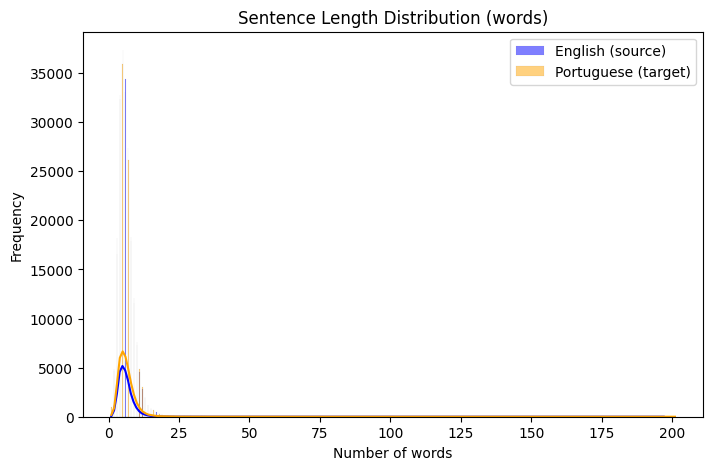

In [ ]:
# sentence length distribution
plt.figure(figsize=(8,5))
sns.histplot(df["src_len"], color="blue", label="English (source)", kde=True)
sns.histplot(df["tgt_len"], color="orange", label="Portuguese (target)", kde=True)
plt.legend()
plt.title("Sentence Length Distribution (words)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

It is possible to observe that **most sentences in the dataset are relatively short**.  
To obtain a **more diverse and representative sample** for metric evaluation, it is important to **also include the few longer sentences**.  
This helps ensure that the translation metric is tested across a wider range of linguistic complexities and sentence lengths.

In [ ]:
print(df.head(100).to_string(index=False))

src_lang tgt_lang                                                                                                                                             source                                                                                                                                                   target  src_len  tgt_len
     eng      por                                                                                                                       100 euros for the whole day.                                                                                                                               Cem euros para o dia todo.        6        6
     eng      por                                                                                                            10% of the inhabitants come from Japan.                                                                                                                         10% dos habitantes vêm do Japão.        7  

## Are there dupllicated sentences?

In [ ]:
# Number of unique English source sentences
n_unique = df["source"].nunique()

# Total number of rows
n_total = len(df)

# Duplicated sources (appear more than once)
dup_counts = df["source"].value_counts()
n_duplicates = (dup_counts > 1).sum()

print(f"Total rows: {n_total}")
print(f"Unique sources: {n_unique}")
print(f"Duplicated sources: {n_duplicates}")
print(f"→ {n_total - n_unique} duplicated rows in total")

Total rows: 204462
Unique sources: 163464
Duplicated sources: 29940
→ 40998 duplicated rows in total


Some source sentences have multiple possible targets, which is not desirable for our analysis since we aim to maximize sample diversity. Given that our system, which relies on agents, cannot process a large number of samples, we prioritize having distinct source–target pairs instead of multiple variants for the same source.

# 🤖 Agent Analysis

#### The original framework assigns different agents to distinct data types. It is necessary to determine whether our dataset covers all those types or whether certain categories can be omitted for our current evaluation.

In [ ]:
import re

patterns = {
    # Currency (supports $, €, £, R$, USD, etc.)
    "currency": re.compile(
        r"(\$\s?\d+([.,]\d+)?|\d+([.,]\d+)?\s?(euros?|dollars?|reais?|pounds?|£|€|USD|R\$))",
        re.IGNORECASE
    ),

    # Phone (supports +country, parentheses, spaces, dashes)
    "phone": re.compile(
        r"(\+?\d{1,3}?[-.\s]?\(?\d{1,4}\)?[-.\s]?\d{2,4}[-.\s]?\d{2,4})"
    ),

    # Address (basic detection of numeric + street-type word)
    "address": re.compile(
        r"\b(\d+\s+[A-Za-zÀ-ÿ\s]+(Street|St\.|Avenue|Ave\.|Road|Rd\.|Rua|Av\.|Blvd\.|Boulevard|R\.))\b",
        re.IGNORECASE
    ),

    # Date (only numeric, like 12/05/2018 or 01-01-20)
    "date": re.compile(
        r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b"
    ),

    # Time (e.g. 14:30, 9:00 am, 11h45)
    "time": re.compile(
        r"\b(\d{1,2}[:h]\d{2}(\s?(am|pm))?)\b",
        re.IGNORECASE
    )
}

for key, pattern in patterns.items():
    df[f"has_{key}"] = df["source"].apply(lambda x: bool(pattern.search(str(x))))

summary = {key: int(df[f"has_{key}"].sum()) for key in patterns.keys()}

print("Entity detection summary (in 'source')")
for k, v in summary.items():
    print(f"{k.capitalize():<10}: {v} sentences detected")

# show examples per entity
for key in patterns.keys():
    examples = df[df[f"has_{key}"]][["source", "target"]].head(20)
    if not examples.empty:
        print(f"\n--- Examples with {key} ---")
        print(examples.to_string(index=False))

Entity detection summary (in 'source')
Currency  : 105 sentences detected
Phone     : 14 sentences detected
Address   : 3 sentences detected
Date      : 1 sentences detected
Time      : 305 sentences detected

--- Examples with currency ---
                                                                                                                                          source                                                                                                                                            target
                                                                                                                    100 euros for the whole day.                                                                                                                        Cem euros para o dia todo.
                                                                                                                      40 dollars for seven days.                                 

Since our dataset contains very few samples related to phone numbers, addresses, and dates, we will not include agents dedicated to these data types.

 # 🇵 Entities and Proper Names Analysis

 Named entities and proper names often pose significant challenges for neural machine translation (NMT) systems. Therefore, we aim to include a large number of such examples in our sample to better evaluate metric performance on these difficult cases.

In [ ]:
import spacy

In [ ]:
nlp = spacy.load("en_core_web_sm")

In [ ]:
# Sample 20% of the data
df_sample = df.sample(frac=0.2, random_state=42).reset_index(drop=True)

# Entity labels to exclude
EXCLUDE_ENTS = {"DATE", "TIME", "PERCENT", "MONEY", "QUANTITY", "ORDINAL", "CARDINAL"}

# Apply NER only to the "source" column
entities = []
for text in df_sample["source"].dropna():
    doc = nlp(text)
    ent_labels = [ent.label_ for ent in doc.ents if ent.label_ not in EXCLUDE_ENTS]
    entities.append(ent_labels)

df_sample["entities"] = entities

# Count sentences that contain at least one *non-excluded* entity
has_entities = df_sample["entities"].apply(lambda x: len(x) > 0)
num_with_entities = has_entities.sum()
num_total = len(df_sample)
print(f"Sentences with named entities (excluding numeric/time types): {num_with_entities}/{num_total} ({num_with_entities/num_total:.2%})")

# Count sentences that contain proper names (PERSON)
has_proper_names = df_sample["entities"].apply(lambda ents: "PERSON" in ents)
num_with_proper_names = has_proper_names.sum()
print(f"Sentences with proper names (PERSON): {num_with_proper_names}/{num_total} ({num_with_proper_names/num_total:.2%})")

# Show samples
print("\n=== Sample sentences with filtered entities ===")
print(df_sample[has_entities][["source", "entities"]].head(10).to_string(index=False))

print("\n=== Sample sentences with proper names ===")
print(df_sample[has_proper_names][["source", "entities"]].head(10).to_string(index=False))

Sentences with named entities (excluding numeric/time types): 11913/40892 (29.13%)
Sentences with proper names (PERSON): 9273/40892 (22.68%)

=== Sample sentences with filtered entities ===
                                     source                 entities
            Tom asked Mary to talk to John. [PERSON, PERSON, PERSON]
                 Can you speak French well?                   [NORP]
Speech is worth silver, silence worth gold.                    [ORG]
                 I study Chinese every day.                   [NORP]
   Tom was sentenced to 20 years in prison.                 [PERSON]
               Tom won't eat lunch with us.                 [PERSON]
        Sami was a 32-year-old traffic cop.                    [ORG]
 Why is there no mobile version of Tatoeba?                    [ORG]
                    Tom will never find it.                 [PERSON]
                           Tom was invited.                 [PERSON]

=== Sample sentences with proper names ===
       

# 🔎 Dataset Filtering

Since our dataset contains a significant number of sentences involving currency, time and entities expressions, we will include these data types in our test set to ensure broader coverage of real-world translation scenarios.


In [ ]:
# Filter rows that contain currency or time
filtered_df = df[df["has_currency"] | df["has_time"]].copy()

# Optional: mark which type(s) were found
filtered_df["entity_type"] = filtered_df.apply(
    lambda row: ", ".join(
        [k for k in ["currency", "time"] if row[f"has_{k}"]]
    ),
    axis=1
)

# Keep only relevant columns
numbers_df = filtered_df[["source", "target", "entity_type"]]

# Show some samples
print(numbers_df.head(20).to_string(index=False))

                                                                                                                                          source                                                                                                                                            target entity_type
                                                                                                                    100 euros for the whole day.                                                                                                                        Cem euros para o dia todo.    currency
                                                                                                                      40 dollars for seven days.                                                                                                                  Quarenta dólares para sete dias.    currency
                                                 A pair of Ronald Reagan's cowboy boots, wh

In [ ]:
# Explode to have one entity per row
df_entities = df_sample[["source", "target", "entities"]].explode("entities").dropna().reset_index(drop=True)

# Limit PERSON entities to 300
df_person = df_entities[df_entities["entities"] == "PERSON"].sample(
    n=min(300, len(df_entities[df_entities["entities"] == "PERSON"])),
    random_state=42
)

# Fill the remaining quota with non-PERSON entities
remaining_n = 1000 - len(df_person)
df_others = df_entities[df_entities["entities"] != "PERSON"].sample(
    n=min(remaining_n, len(df_entities[df_entities["entities"] != "PERSON"])),
    random_state=42
)

# Combine and shuffle
df_final_sample = pd.concat([df_person, df_others]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Final dataset created with {len(df_final_sample)} entity mentions")
print(df_final_sample["entities"].value_counts())
print(df_final_sample.head(10).to_string(index=False))


Final dataset created with 1000 entity mentions
entities
GPE            306
PERSON         300
NORP           167
LANGUAGE        97
ORG             86
LOC             20
WORK_OF_ART      9
FAC              6
PRODUCT          5
EVENT            4
Name: count, dtype: int64
                                                          source                                                        target entities
                                Minsk is the capital of Belarus.                            Minsk é a capital da Bielorrússia.      GPE
                            Tom has a restaurant on Park Street.                      O Tom tem um restaurante na Park Street.      FAC
                                          That was Fadil's view.                                    Essa era a visão de Fadil.      GPE
     I wish I had had the chance to learn French in high school. Queria ter tido a chance de aprender francês no ensino médio.     NORP
                                     Lazarus Za

We also aim to include sentences with a wide range of lengths to capture different structural and syntactic complexities.

In [ ]:
# Take 500 shortest + 500 longest sentences
shortest_500 = df.nsmallest(500, "src_len")
longest_500  = df.nlargest(500, "src_len")

# Combine and shuffle
df_length_varied = pd.concat([shortest_500, longest_500]) \
                     .sample(frac=1, random_state=42) \
                     .reset_index(drop=True)

# Keep essential columns (source + target + metadata)
cols_to_keep = [col for col in ["source", "target", "source_len"] if col in df_length_varied.columns]
df_length_varied = df_length_varied[cols_to_keep]

print(f"Created new dataset with {len(df_length_varied)} samples varying sentence length")
print(df_length_varied["source_len"].describe())

print("\n=== Sample preview ===")
print(df_length_varied.head(10).to_string(index=False))

Created new dataset with 1000 samples varying sentence length
count    1000.00000
mean       20.03300
std        23.40093
min         1.00000
25%         1.00000
50%        14.00000
75%        33.00000
max       197.00000
Name: source_len, dtype: float64

=== Sample preview ===
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   source                                                                                                                                                                                                        

In [ ]:
# Combine all three datasets
dfs = [df_length_varied, df_final_sample, numbers_df]

# Ensure valid structure
for name, d in zip(["df_length_varied", "df_final_sample", "numbers_df"], dfs):
    if not set(["source", "target"]).issubset(d.columns):
        raise ValueError(f"{name} is missing 'source' or 'target' columns")

# Concatenate
final_balanced_dataset = pd.concat(dfs, ignore_index=True)

# Keep only source and target
final_balanced_dataset = final_balanced_dataset[["source", "target"]]

# Remove duplicates (by both source and target)
final_balanced_dataset = final_balanced_dataset.drop_duplicates(subset=["source", "target"]).reset_index(drop=True)

# Shuffle the final dataset
final_balanced_dataset = final_balanced_dataset.sample(frac=1, random_state=42).reset_index(drop=True)

# Save to Google Drive
output_path = "/content/gdrive/MyDrive/PROJETO_FINAL/Data/final_balanced_dataset.txt"
final_balanced_dataset.to_csv(output_path, sep="\t", index=False, header=True)

print(f"Final dataset created with {len(final_balanced_dataset)} unique rows (duplicates removed).")
print(f"Saved to: {output_path}")
print("\n=== Sample preview ===")
print(final_balanced_dataset.head(10).to_string(index=False))

Final dataset created with 2365 unique rows (duplicates removed).
Saved to: /content/gdrive/MyDrive/PROJETO_FINAL/Data/final_balanced_dataset.txt

=== Sample preview ===
                                                                                                                                                     source                                                                                                                                                                                                                           target
                                                                                                                  Tom is still willing to do that for free.                                                                                                                                                                                         Tom está disposto a fazer isso de graça.
                                                                    

# 🏳 Translation

In [ ]:
import pandas as pd
from openai import OpenAI
import time

In [ ]:
# Setup client
client = OpenAI(api_key="")

input_path = "/content/gdrive/MyDrive/PROJETO_FINAL/Data/final_balanced_dataset.txt"
df = pd.read_csv(input_path, sep="\t", usecols=["source"])

In [ ]:
df

,source
0,Tom is still willing to do that for free.
1,Tom bought Mary something.
2,I went to Nagasaki.
3,"For example, it is 7:00 a.m. in London now."
4,My Spanish is terrible.
...,...
2360,I'm also thinking of going to Australia.
2361,I'm pretty sure that Tom didn't know Mary was ...
2362,Tom can never remember how to spell my name.
2363,Do you study French?


In [ ]:
# Prepare output
translations = []
batch_size = 1000

# Batch translation loop
for start in range(0, len(df), batch_size):
    end = min(start + batch_size, len(df))
    batch = df.iloc[start:end]["source"].tolist()

    print(f"Translating rows {start}–{end}...")

    # Combine batch into one prompt
    batch_text = "\n".join([f"{i+1}. {text}" for i, text in enumerate(batch)])
    prompt = (
        "You are a professional Brazilian Portuguese translator. "
        "Translate each English sentence below into natural-sounding Brazilian Portuguese. "
        "Return only the translations in the same order, numbered 1–N.\n\n"
        f"{batch_text}"
    )

    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",  # GPT-4-Nano equivalent
            messages=[{"role": "user", "content": prompt}],
            temperature=0.2,
            max_tokens=2000,
        )
        translated_text = response.choices[0].message.content.strip().split("\n")
        # Clean and align
        cleaned = [t.split(". ", 1)[-1].strip() for t in translated_text if t.strip()]
        # Pad if mismatch
        while len(cleaned) < len(batch):
            cleaned.append("")
        translations.extend(cleaned[:len(batch)])

    except Exception as e:
        print("Error:", e)
        # Fill failed batch with blanks
        translations.extend([""] * len(batch))
        time.sleep(5)

df["gpt_translation"] = translations
output_path = "/content/gdrive/MyDrive/PROJETO_FINAL/Data/final_translated_dataset.txt"
df.to_csv(output_path, sep="\t", index=False, header=True)

print(f"Translation completed and saved to: {output_path}")
print(df.head())


Translating rows 0–1000...
Translating rows 1000–2000...
Translating rows 2000–2365...
Translation completed and saved to: /content/gdrive/MyDrive/PROJETO_FINAL/Data/final_translated_dataset.txt
                                        source  \
0    Tom is still willing to do that for free.   
1                   Tom bought Mary something.   
2                          I went to Nagasaki.   
3  For example, it is 7:00 a.m. in London now.   
4                      My Spanish is terrible.   

                                    gpt_translation  
0    Tom ainda está disposto a fazer isso de graça.  
1                     Tom comprou algo para a Mary.  
2                                Eu fui a Nagasaki.  
3  Por exemplo, agora são 7:00 da manhã em Londres.  
4                          Meu espanhol é terrível.  
